In [20]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("cancer-risk-factors.csv")

In [5]:
df.head()

,Patient_ID,Cancer_Type,Age,Gender,Smoking,Alcohol_Use,Obesity,Family_History,Diet_Red_Meat,Diet_Salted_Processed,...,Physical_Activity,Air_Pollution,Occupational_Hazards,BRCA_Mutation,H_Pylori_Infection,Calcium_Intake,Overall_Risk_Score,BMI,Physical_Activity_Level,Risk_Level
0,LU0000,Breast,68,0,7,2,8,0,5,3,...,4,6,3,1,0,0,0.398696,28.0,5,Medium
1,LU0001,Prostate,74,1,8,9,8,0,0,3,...,1,3,3,0,0,5,0.424299,25.4,9,Medium
2,LU0002,Skin,55,1,7,10,7,0,3,3,...,1,8,10,0,0,6,0.605082,28.6,2,Medium
3,LU0003,Colon,61,0,6,2,2,0,6,2,...,6,4,8,0,0,8,0.318449,32.1,7,Low
4,LU0004,Lung,67,1,10,7,4,0,6,3,...,9,10,9,0,0,5,0.524358,25.1,2,Medium


## Identification
- Patient ID - Unique ID for each patient
- Cancer Type - The type of cancer diagnosed

## General Characteristics
- Age
- Gender
- BMI - Body Mass Index

## Lifestyle & Environmental Factors
- Smoking
- Alcohol Type
- Obesity
- Diet Red Meat
- Diet Salted Processed
- Fruit Veg Intake
- Physical Activity
- Air Pollution
- Occupational Hazards
- Calcium Intake

## Medical Factors
- Family History
- BRCA Mutation
- H_Pylori_Infection

## Engineered (Calculated Features)
- Overall Risk Score
- Risk Level

## What to Predict?
- Risk Level


In [6]:
df.Cancer_Type.value_counts()

Cancer_Type
Lung        527
Breast      460
Colon       418
Prostate    305
Skin        290
Name: count, dtype: int64

## Understanding data with EDA

In [7]:
risk_counts = df["Risk_Level"].value_counts()
print(risk_counts)

Risk_Level
Medium    1574
Low        324
High       102
Name: count, dtype: int64


<Axes: ylabel='Risk_Level'>

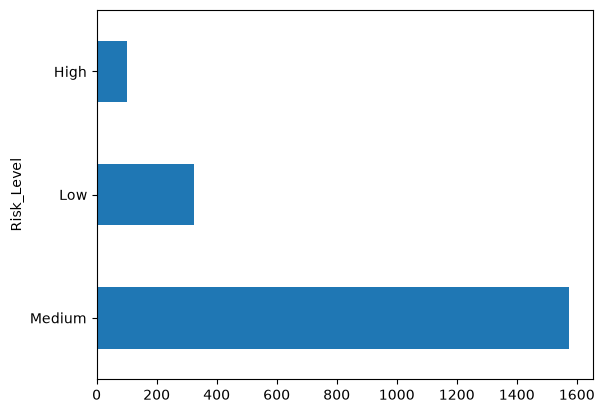

In [8]:
df['Risk_Level'].value_counts().plot(kind='barh')

In [9]:
df['Risk_Level'].value_counts()/len(df)*100

Risk_Level
Medium    78.7
Low       16.2
High       5.1
Name: count, dtype: float64

## the data is highly imbalanced
- Low: 16.2%
- Medium: 78.7
- High: 5.1

In [10]:
df.head()

,Patient_ID,Cancer_Type,Age,Gender,Smoking,Alcohol_Use,Obesity,Family_History,Diet_Red_Meat,Diet_Salted_Processed,...,Physical_Activity,Air_Pollution,Occupational_Hazards,BRCA_Mutation,H_Pylori_Infection,Calcium_Intake,Overall_Risk_Score,BMI,Physical_Activity_Level,Risk_Level
0,LU0000,Breast,68,0,7,2,8,0,5,3,...,4,6,3,1,0,0,0.398696,28.0,5,Medium
1,LU0001,Prostate,74,1,8,9,8,0,0,3,...,1,3,3,0,0,5,0.424299,25.4,9,Medium
2,LU0002,Skin,55,1,7,10,7,0,3,3,...,1,8,10,0,0,6,0.605082,28.6,2,Medium
3,LU0003,Colon,61,0,6,2,2,0,6,2,...,6,4,8,0,0,8,0.318449,32.1,7,Low
4,LU0004,Lung,67,1,10,7,4,0,6,3,...,9,10,9,0,0,5,0.524358,25.1,2,Medium


In [13]:
df.Gender.value_counts()

Gender
0    1022
1     978
Name: count, dtype: int64

<Axes: xlabel='Cancer_Type'>

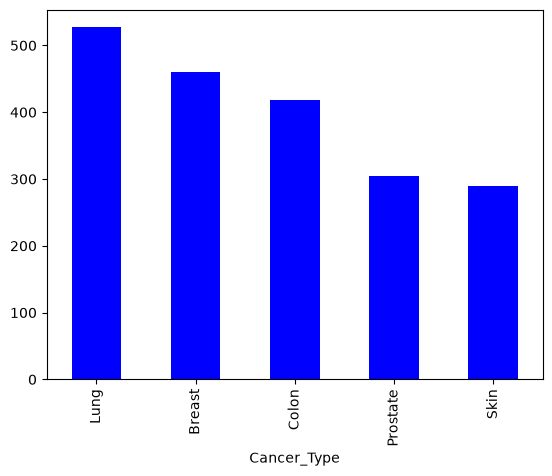

In [17]:
df.Cancer_Type.value_counts().plot(kind='bar', color='blue')

In [19]:
gender_cancer_counts = df.groupby(['Gender', 'Cancer_Type']).size().reset_index(name='Patient_Count')
gender_cancer_counts["Gender"] = gender_cancer_counts["Gender"].map({0: "Female", 1: "Male"})
print(gender_cancer_counts)

   Gender Cancer_Type  Patient_Count
0  Female      Breast            455
1  Female       Colon            197
2  Female        Lung            238
3  Female        Skin            132
4    Male      Breast              5
5    Male       Colon            221
6    Male        Lung            289
7    Male    Prostate            305
8    Male        Skin            158


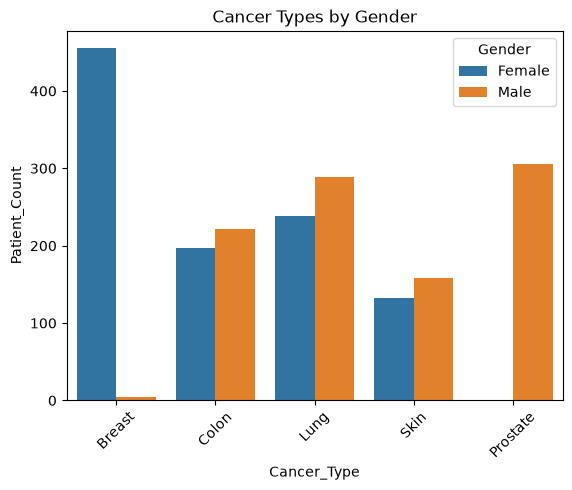

In [21]:
sns.barplot(data=gender_cancer_counts, x='Cancer_Type', y='Patient_Count', hue='Gender')
plt.title('Cancer Types by Gender')
plt.xticks(rotation=45)
plt.show()

In [23]:
# finding all patients under 35
young_patients = df[df['Age'] < 35]
print(young_patients)


    Patient_ID Cancer_Type  Age  Gender  Smoking  Alcohol_Use  Obesity  \
420     BR0020        Skin   32       0        1            3        8   
433     BR0033        Lung   25       0        8            6        5   
454     BR0054        Lung   29       0        8            6        7   
468     BR0068        Lung   32       0        8            2        0   
495     BR0095      Breast   31       0        1            9       10   
585     BR0185        Lung   34       0        6            8        5   
593     BR0193      Breast   34       0        5            1       10   
621     BR0221        Lung   25       0        7           10        6   
698     BR0298        Lung   34       0        8            0        2   

     Family_History  Diet_Red_Meat  Diet_Salted_Processed  ...  \
420               0              5                      1  ...   
433               0              3                      5  ...   
454               0              3                      0  ..

In [24]:
count_young = (df['Age'] < 35).sum()
print(f"Number of patients under 35: {count_young}")

Number of patients under 35: 9


In [25]:
young_cancer_types = df[df['Age'] < 35]['Cancer_Type'].value_counts()
print(young_cancer_types)

Cancer_Type
Lung      6
Breast    2
Skin      1
Name: count, dtype: int64


This shows which csncer types appear among young patients and how many cases of each

In [26]:
## Finding out which factors highly contribute to high risk level

# Select only numerical columns
numeric_columns = df.select_dtypes(include=[np.number]).columns

# Compute the mean of each numeric feature per risk level
risk_means = df.groupby('Risk_Level')[numeric_columns].mean().T

print(risk_means)
 

Risk_Level                    High        Low     Medium
Age                      63.745098  63.685185  63.125794
Gender                    0.509804   0.493827   0.486658
Smoking                   7.519608   2.845679   5.479670
Alcohol_Use               7.519608   2.984568   5.296061
Obesity                   7.274510   4.824074   6.118170
Family_History            0.205882   0.138889   0.205210
Diet_Red_Meat             7.362745   3.972222   5.299238
Diet_Salted_Processed     7.039216   2.888889   4.747776
Fruit_Veg_Intake          3.911765   5.666667   4.841169
Physical_Activity         4.921569   3.669753   4.027319
Air_Pollution             8.539216   2.947531   5.603558
Occupational_Hazards      6.990196   3.364198   5.181067
BRCA_Mutation             0.049020   0.037037   0.030496
H_Pylori_Infection        0.245098   0.175926   0.197586
Calcium_Intake            4.323529   3.651235   3.975222
Overall_Risk_Score        0.699991   0.269458   0.476616
BMI                      26.225

## Insights

- Heavy smokers are much more likely to be High Risk.
- Similar to smoking, high alcohol use is strongly linked to High Risk.
- High red meat consumption is associated with High Risk.
- High intake of salted/processed foods is strongly linked to High Risk.
- Exposure to high air pollution is a major differentiator for High Risk.
- Jobs with hazardous exposures push risk higher.
- Higher obesity levels correlate with higher risk.

In [28]:
## Focus on difference between High and Low Risk
risk_diff = risk_means['High'] - risk_means['Low']
risk_diff = risk_diff.sort_values(ascending=False)
print(risk_diff)

Air_Pollution              5.591685
Smoking                    4.673929
Alcohol_Use                4.535040
Diet_Salted_Processed      4.150327
Occupational_Hazards       3.625999
Diet_Red_Meat              3.390523
Obesity                    2.450436
Physical_Activity          1.251816
Calcium_Intake             0.672295
Overall_Risk_Score         0.430533
BMI                        0.410984
Physical_Activity_Level    0.337509
H_Pylori_Infection         0.069172
Family_History             0.066993
Age                        0.059913
Gender                     0.015977
BRCA_Mutation              0.011983
Fruit_Veg_Intake          -1.754902
dtype: float64


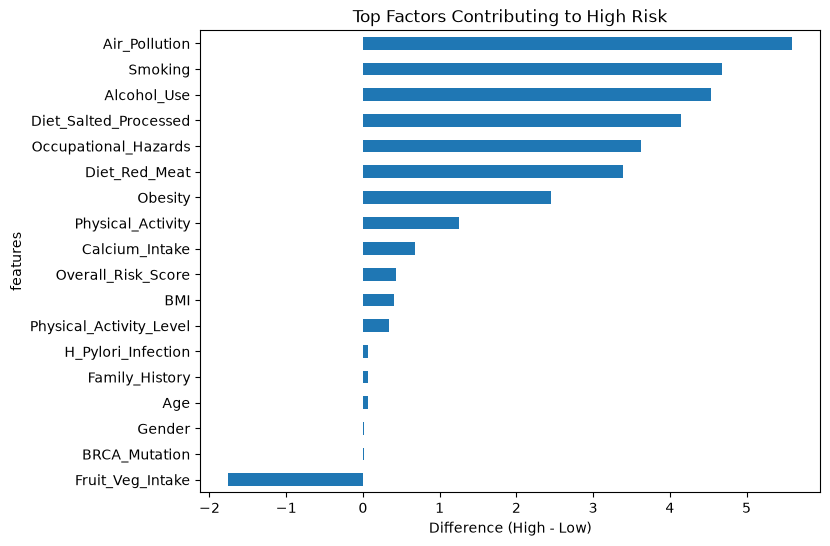

In [29]:
risk_diff.sort_values(ascending=True).plot(
    kind='barh',
    figsize=(8,6),
    title='Top Factors Contributing to High Risk'
)

plt.xlabel('Difference (High - Low)')
plt.ylabel('features')
plt.show()

## Air Pollution, Smoking, lcohol use are top 3 contributing factors in high risk level

In [31]:
bmi_by_risk = df.groupby('Risk_Level')['BMI'].mean()    
print(bmi_by_risk)

Risk_Level
High      26.225490
Low       25.814506
Medium    26.256544
Name: BMI, dtype: float64


In [34]:
df.head(5)


,Patient_ID,Cancer_Type,Age,Gender,Smoking,Alcohol_Use,Obesity,Family_History,Diet_Red_Meat,Diet_Salted_Processed,...,Physical_Activity,Air_Pollution,Occupational_Hazards,BRCA_Mutation,H_Pylori_Infection,Calcium_Intake,Overall_Risk_Score,BMI,Physical_Activity_Level,Risk_Level
0,LU0000,Breast,68,0,7,2,8,0,5,3,...,4,6,3,1,0,0,0.398696,28.0,5,Medium
1,LU0001,Prostate,74,1,8,9,8,0,0,3,...,1,3,3,0,0,5,0.424299,25.4,9,Medium
2,LU0002,Skin,55,1,7,10,7,0,3,3,...,1,8,10,0,0,6,0.605082,28.6,2,Medium
3,LU0003,Colon,61,0,6,2,2,0,6,2,...,6,4,8,0,0,8,0.318449,32.1,7,Low
4,LU0004,Lung,67,1,10,7,4,0,6,3,...,9,10,9,0,0,5,0.524358,25.1,2,Medium


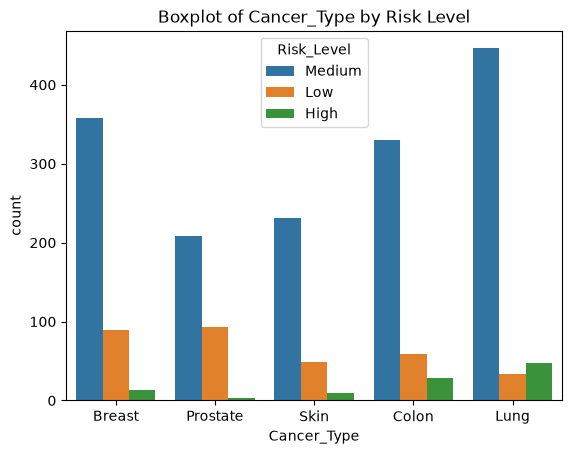

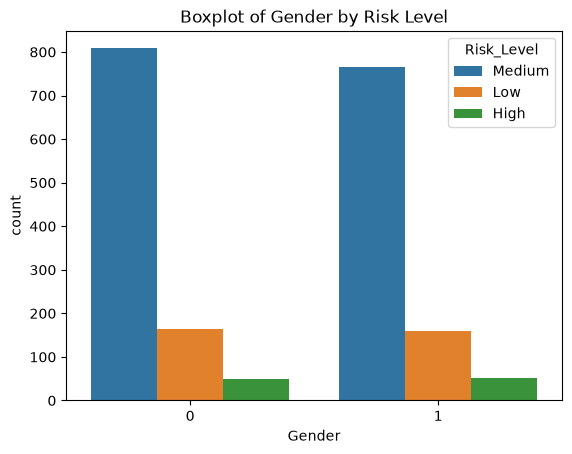

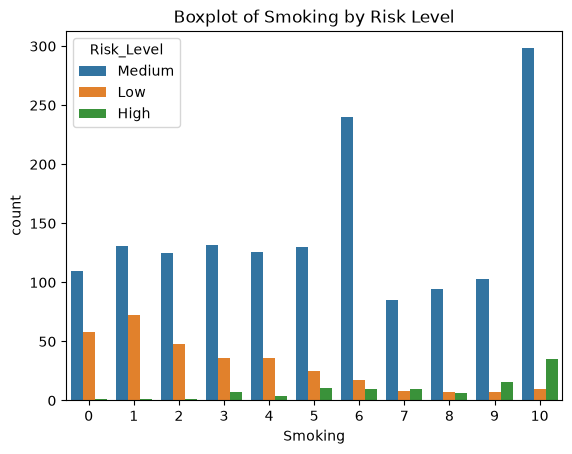

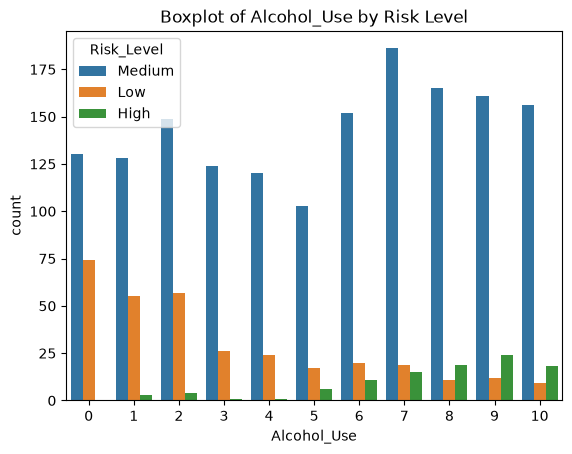

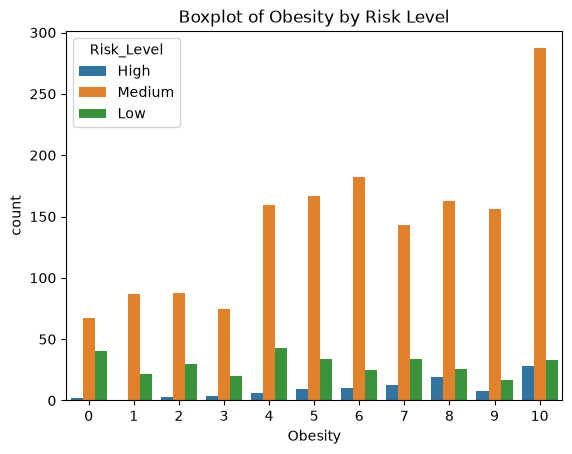

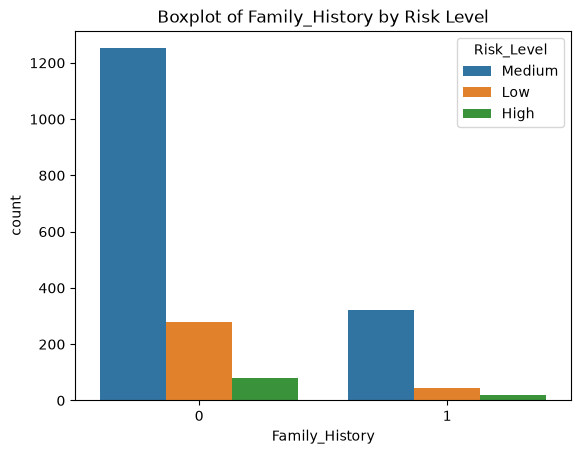

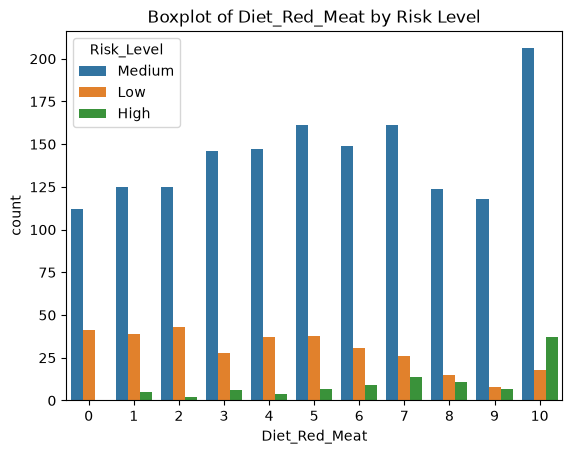

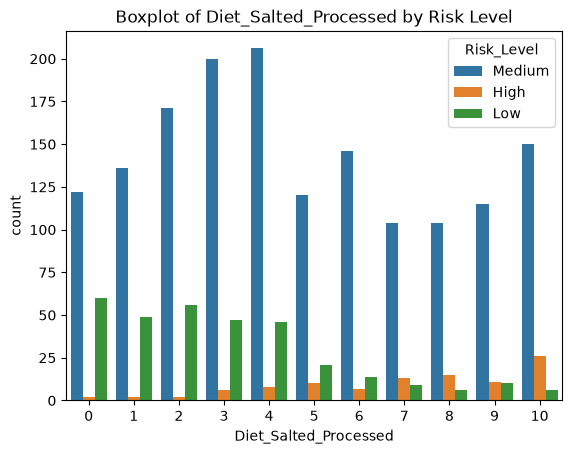

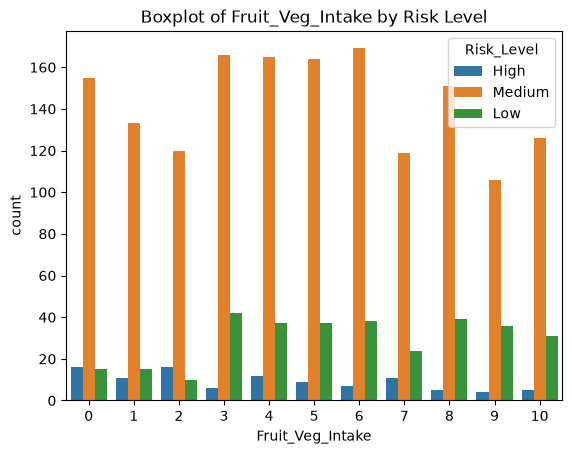

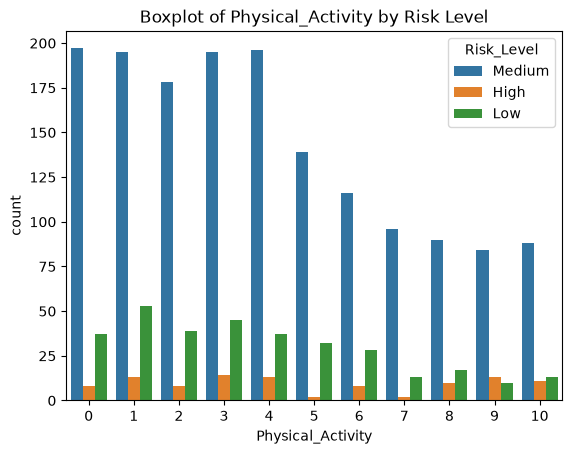

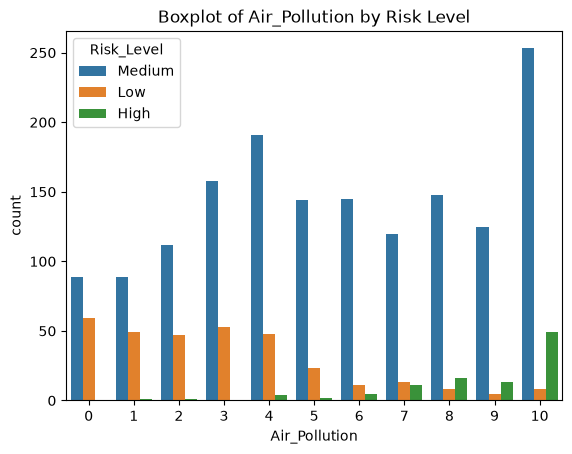

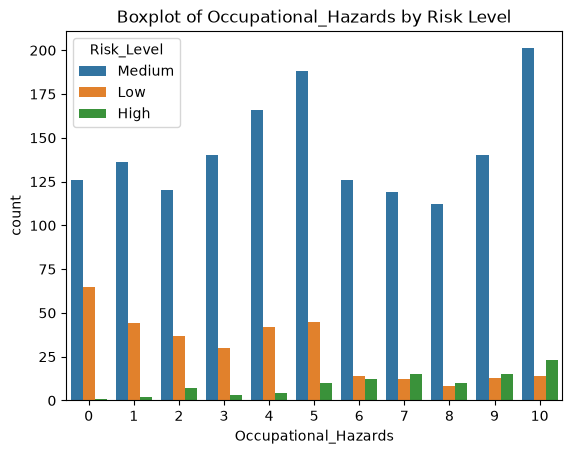

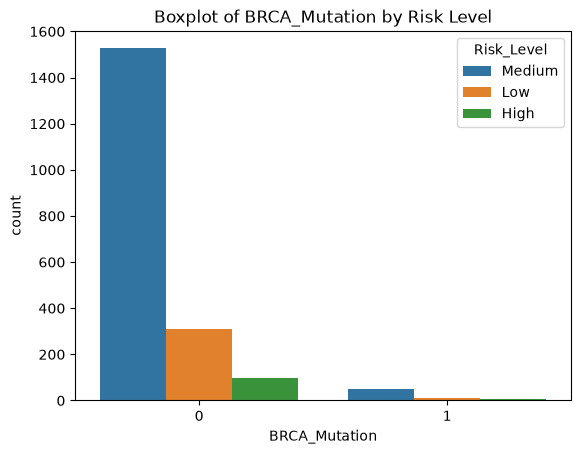

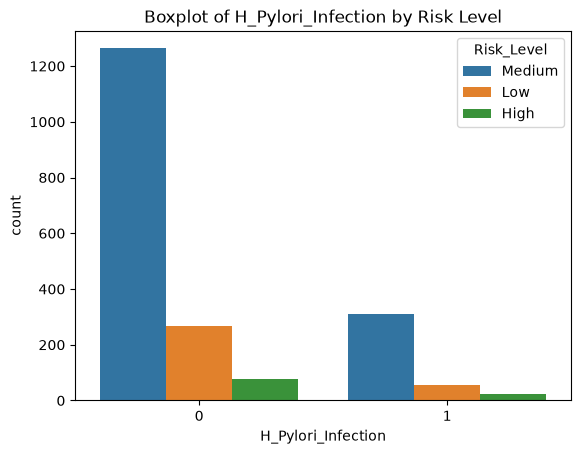

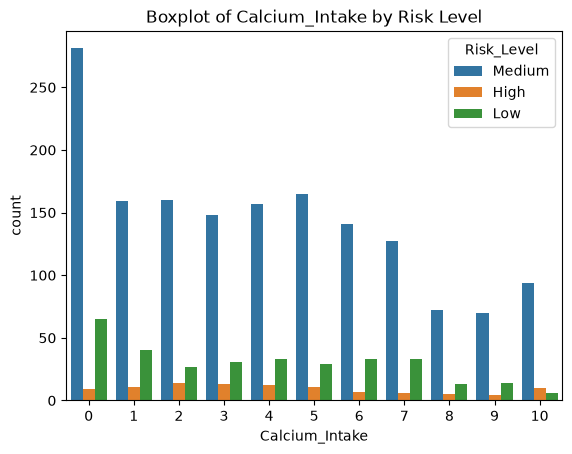

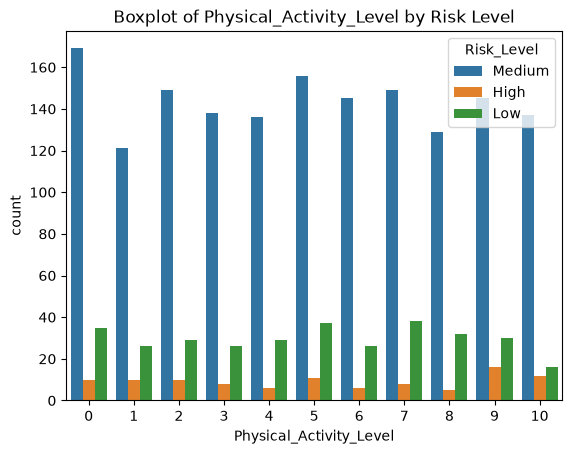

In [36]:
for i, predictor in enumerate(df.drop(columns=['Patient_ID', 'Risk_Level', 'Age','Overall_Risk_Score','BMI'])):
    plt.figure(i)
    sns.countplot(hue='Risk_Level', x=predictor, data=df)
    plt.title(f'Boxplot of {predictor} by Risk Level')
    plt.show()

## Numerical analysis


In [37]:
df.head(5)

,Patient_ID,Cancer_Type,Age,Gender,Smoking,Alcohol_Use,Obesity,Family_History,Diet_Red_Meat,Diet_Salted_Processed,...,Physical_Activity,Air_Pollution,Occupational_Hazards,BRCA_Mutation,H_Pylori_Infection,Calcium_Intake,Overall_Risk_Score,BMI,Physical_Activity_Level,Risk_Level
0,LU0000,Breast,68,0,7,2,8,0,5,3,...,4,6,3,1,0,0,0.398696,28.0,5,Medium
1,LU0001,Prostate,74,1,8,9,8,0,0,3,...,1,3,3,0,0,5,0.424299,25.4,9,Medium
2,LU0002,Skin,55,1,7,10,7,0,3,3,...,1,8,10,0,0,6,0.605082,28.6,2,Medium
3,LU0003,Colon,61,0,6,2,2,0,6,2,...,6,4,8,0,0,8,0.318449,32.1,7,Low
4,LU0004,Lung,67,1,10,7,4,0,6,3,...,9,10,9,0,0,5,0.524358,25.1,2,Medium


In [38]:
df = df.drop(columns=['Patient_ID'])


In [39]:
df['Risk_Level'] = df['Risk_Level'].map({'Low': 0, 'Medium': 1, 'High': 2})

In [40]:
df.head(5)

,Cancer_Type,Age,Gender,Smoking,Alcohol_Use,Obesity,Family_History,Diet_Red_Meat,Diet_Salted_Processed,Fruit_Veg_Intake,Physical_Activity,Air_Pollution,Occupational_Hazards,BRCA_Mutation,H_Pylori_Infection,Calcium_Intake,Overall_Risk_Score,BMI,Physical_Activity_Level,Risk_Level
0,Breast,68,0,7,2,8,0,5,3,7,4,6,3,1,0,0,0.398696,28.0,5,1
1,Prostate,74,1,8,9,8,0,0,3,7,1,3,3,0,0,5,0.424299,25.4,9,1
2,Skin,55,1,7,10,7,0,3,3,4,1,8,10,0,0,6,0.605082,28.6,2,1
3,Colon,61,0,6,2,2,0,6,2,4,6,4,8,0,0,8,0.318449,32.1,7,0
4,Lung,67,1,10,7,4,0,6,3,10,9,10,9,0,0,5,0.524358,25.1,2,1


In [41]:
df_dummies = pd.get_dummies(df)
df_dummies.head(5)

,Age,Gender,Smoking,Alcohol_Use,Obesity,Family_History,Diet_Red_Meat,Diet_Salted_Processed,Fruit_Veg_Intake,Physical_Activity,...,Calcium_Intake,Overall_Risk_Score,BMI,Physical_Activity_Level,Risk_Level,Cancer_Type_Breast,Cancer_Type_Colon,Cancer_Type_Lung,Cancer_Type_Prostate,Cancer_Type_Skin
0,68,0,7,2,8,0,5,3,7,4,...,0,0.398696,28.0,5,1,True,False,False,False,False
1,74,1,8,9,8,0,0,3,7,1,...,5,0.424299,25.4,9,1,False,False,False,True,False
2,55,1,7,10,7,0,3,3,4,1,...,6,0.605082,28.6,2,1,False,False,False,False,True
3,61,0,6,2,2,0,6,2,4,6,...,8,0.318449,32.1,7,0,False,True,False,False,False
4,67,1,10,7,4,0,6,3,10,9,...,5,0.524358,25.1,2,1,False,False,True,False,False


<Axes: >

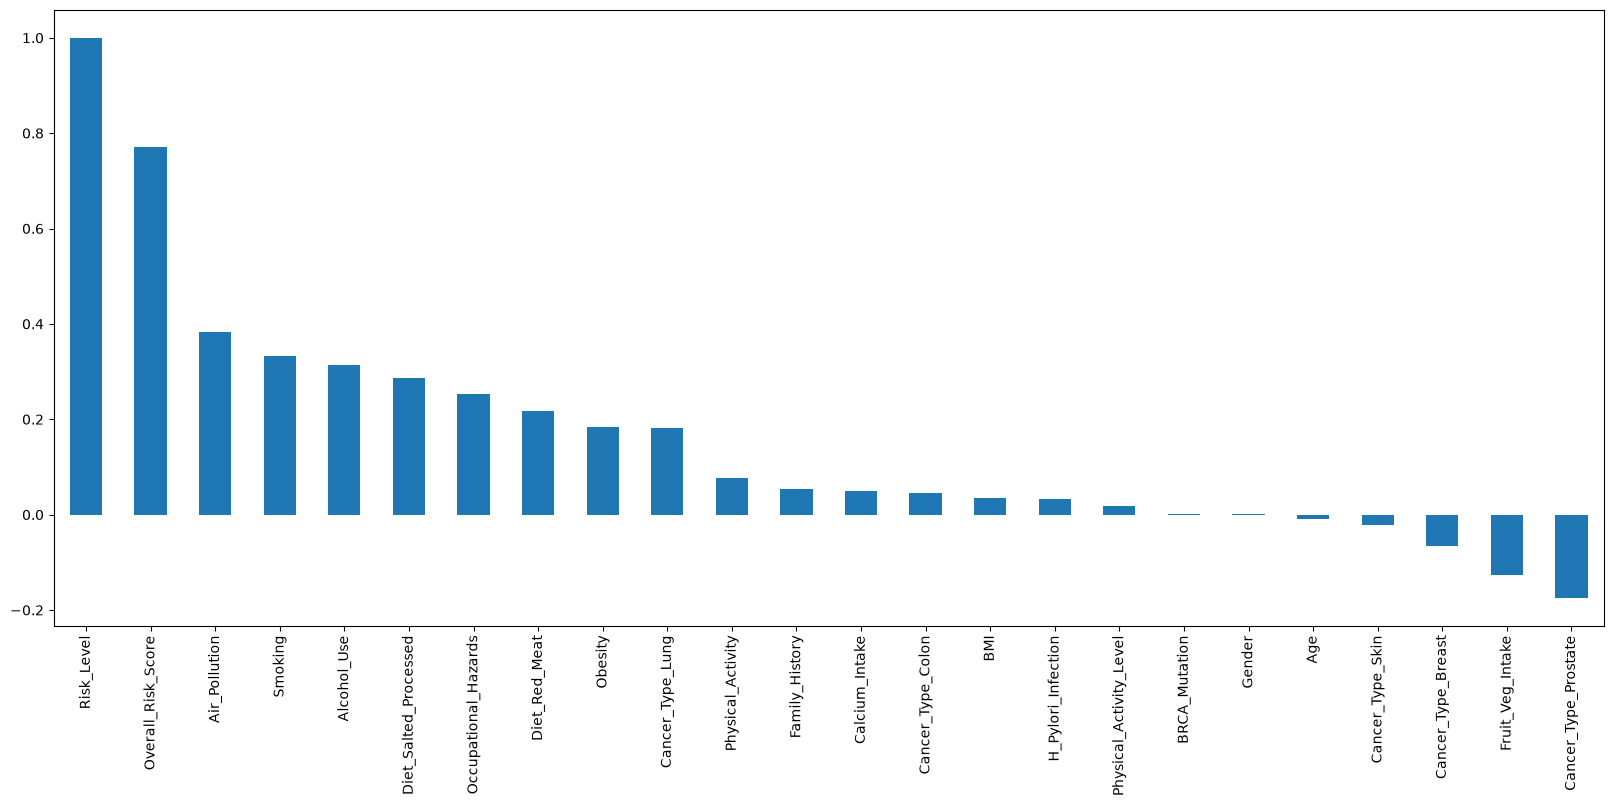

In [46]:
plt.figure(figsize=(20,8))
df_dummies.corr()['Risk_Level'].sort_values(ascending=False).plot(kind='bar')